# Pipeline A (v4): Audio Spoof Detection (ASVspoof2019 LA)

**Goal:** train a CNN on log-mel spectograms to classify bonafide vs spoof speech.

**Outputs:** predicted label + confidence, and evaluation metrics (Accuracy, F1, Confusion Matrix, ROC-AUC, EER

## Setup & Reproducability

In [1]:
# ---- Imports----
import os
import random
import math
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, 
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ---- Reproducibility + Device----
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Configuration

In [3]:
@dataclass
# ==== Config paths + hyperparameters ====
class Config:
    # ==== Paths ====
    BASE_DIR: str = r"C:\FYP\Datasets\ASVspoof2019_LA"

    # ==== Audio / Features ====
    target_sr: int = 16000
    n_mels: int = 64
    n_fft: int = 1024
    hop_length: int = 160     # 10ms @ 16kHz
    win_length: int = 400     # 25ms @ 16kHz
    f_min: int = 20
    f_max: int = 7600

    # Fixed length segment (seconds)
    clip_seconds: float = 4.0

    # ==== Training ====
    batch_size: int = 32
    num_workers: int = 2
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 15

cfg = Config()

from pathlib import Path
BASE_DIR = Path(cfg.BASE_DIR)
print('BASE_DIR:', BASE_DIR)
assert BASE_DIR.exists(), f'Dataset folder not found: {BASE_DIR}'

BASE_DIR.exists(), BASE_DIR


BASE_DIR: C:\FYP\Datasets\ASVspoof2019_LA


(True, WindowsPath('C:/FYP/Datasets/ASVspoof2019_LA'))

In [4]:
# ==== Resolve Dataset paths + protocol files ====
proto_dir = BASE_DIR / "ASVspoof2019_LA_cm_protocols"

def pick_proto(split: str):
    # matches common naming variants
    candidates = list(proto_dir.glob(f"*{split}*.txt"))
    if not candidates:
        raise FileNotFoundError(f"No protocol file found for split='{split}' in {proto_dir}")
    # prefer ones containing ".cm."
    candidates = sorted(candidates, key=lambda p: (".cm." not in p.name, len(p.name)))
    return candidates[0]

train_proto = pick_proto("train")
dev_proto   = pick_proto("dev")
eval_proto  = pick_proto("eval")

print("train_proto:", train_proto.name)
print("dev_proto:  ", dev_proto.name)
print("eval_proto: ", eval_proto.name)

train_proto: ASVspoof2019.LA.cm.train.trn.txt
dev_proto:   ASVspoof2019.LA.cm.dev.trl.txt
eval_proto:  ASVspoof2019.LA.cm.eval.trl.txt


# Protocol Parsing
**bonafide -> 0**

**spoof -> 1**

In [5]:
# ==== Parse protocol Function ====
def parse_asvspoof_protocol(protocol_path: Path):
    """
    Expected format (common for ASVspoof2019 LA CM protocols):
    speaker_id  utt_id  env  attack_id  label
    e.g. LA_0079 LA_T_1138215 - A01 spoof
    """
    items = []
    with open(protocol_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            utt_id = parts[1]
            label_str = parts[-1].lower()
            label = 0 if label_str == "bonafide" else 1
            items.append((utt_id, label))
    return items

train_items = parse_asvspoof_protocol(train_proto)
dev_items   = parse_asvspoof_protocol(dev_proto)
eval_items  = parse_asvspoof_protocol(eval_proto)

len(train_items), len(dev_items), len(eval_items), train_items[:3]

(25380,
 24844,
 71237,
 [('LA_T_1138215', 0), ('LA_T_1271820', 0), ('LA_T_1272637', 0)])

# Preprocessing & Feature Extraction
LogMelExtractor

In [6]:
# ==== Feature extractor (Log-Mel + Normalization) ====
class LogMelExtractor(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.melspec = torchaudio.transforms.MelSpectrogram(
            sample_rate=cfg.target_sr,
            n_fft=cfg.n_fft,
            win_length=cfg.win_length,
            hop_length=cfg.hop_length,
            f_min=cfg.f_min,
            f_max=cfg.f_max,
            n_mels=cfg.n_mels,
            power=2.0
        )
        self.amp_to_db = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)

    def forward(self, wav: torch.Tensor):
        """
        wav: (1, T) float tensor
        returns: (1, n_mels, frames)
        """
        mel = self.melspec(wav)           # (1, n_mels, frames)
        logmel = self.amp_to_db(mel)
        # per-utterance normalization (z-score)
        mean = logmel.mean()
        std = logmel.std().clamp_min(1e-6)
        logmel = (logmel - mean) / std
        return logmel

extractor = LogMelExtractor(cfg).to(device)

# Dataset & DataLoaders
Dataset class, loaders, sampler

In [7]:
# ==== Utility: load audio + Fix length ====
def load_audio(path, target_sr: int):
    # soundfile returns float64 by default sometimes; force float32
    wav_np, sr = sf.read(str(path), dtype="float32", always_2d=True)  # shape: (T, C)
    wav = torch.from_numpy(wav_np).transpose(0, 1)  # -> (C, T)

    # mono
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)

    # resample if needed
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)

    return wav

def fix_length(wav: torch.Tensor, target_len: int):
    """
    wav: (1, T)
    target_len: samples
    """
    T = wav.shape[-1]
    if T == target_len:
        return wav
    if T > target_len:
        return wav[..., :target_len]
    # pad if shorter
    pad_amount = target_len - T
    return F.pad(wav, (0, pad_amount))

In [8]:
# ==== Dataset Class ====
class ASVSpoofDataset(Dataset):
    def __init__(self, items, audio_dir: Path, cfg: Config, extractor: nn.Module, device: torch.device):
        self.items = items
        self.audio_dir = audio_dir
        self.cfg = cfg
        self.extractor = extractor
        self.device = device
        self.target_len = int(cfg.clip_seconds * cfg.target_sr)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        utt_id, label = self.items[idx]
        wav_path = self.audio_dir / f"{utt_id}.flac"
        wav = load_audio(wav_path, self.cfg.target_sr)
        wav = fix_length(wav, self.target_len)

        # Extract features on GPU for speed
        with torch.no_grad():
            wav_gpu = wav.to(self.device)
            feat = self.extractor(wav_gpu)  # (1, n_mels, frames)
            feat = feat.cpu()

        # Return (channels, mel, frames) as float
        return feat.float(), torch.tensor(label, dtype=torch.long), utt_id

In [9]:
# ==== Resolve audio directories (train/dev/eval) ====
train_dir = BASE_DIR / "ASVspoof2019_LA_train" / "flac"
dev_dir   = BASE_DIR / "ASVspoof2019_LA_dev" / "flac"
eval_dir  = BASE_DIR / "ASVspoof2019_LA_eval" / "flac"

print("train_dir exists:", train_dir.exists(), train_dir)
print("dev_dir exists:  ", dev_dir.exists(), dev_dir)
print("eval_dir exists: ", eval_dir.exists(), eval_dir)

train_dir exists: True C:\FYP\Datasets\ASVspoof2019_LA\ASVspoof2019_LA_train\flac
dev_dir exists:   True C:\FYP\Datasets\ASVspoof2019_LA\ASVspoof2019_LA_dev\flac
eval_dir exists:  True C:\FYP\Datasets\ASVspoof2019_LA\ASVspoof2019_LA_eval\flac


In [10]:
# === Build Datasets ====
train_ds = ASVSpoofDataset(train_items, train_dir, cfg, extractor, device)
dev_ds   = ASVSpoofDataset(dev_items, dev_dir, cfg, extractor, device)
eval_ds  = ASVSpoofDataset(eval_items, eval_dir, cfg, extractor, device)

len(train_ds), len(dev_ds), len(eval_ds)

(25380, 24844, 71237)

In [11]:
x, y, uid = train_ds[0]
print("x shape:", x.shape)      # expected: (1, n_mels, frames)
print("label:", y.item(), "uid:", uid)

x shape: torch.Size([1, 64, 401])
label: 0 uid: LA_T_1138215


In [12]:
# ==== Weighted Sampler (class balance) ==
def make_weighted_sampler_from_items(items):
    labels = np.array([lab for _, lab in items], dtype=np.int64)
    class_counts = np.bincount(labels, minlength=2).astype(np.float32)
    class_weights = 1.0 / np.clip(class_counts, 1.0, None)
    sample_weights = class_weights[labels]
    sample_weights = torch.tensor(sample_weights, dtype=torch.double)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return sampler, class_counts

train_sampler, train_class_counts = make_weighted_sampler_from_items(train_items)
print("Train class counts [bonafide, spoof]:", train_class_counts)

Train class counts [bonafide, spoof]: [ 2580. 22800.]


In [13]:
# ==== DataLoaders ====

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    sampler=train_sampler, 
    shuffle=False,           
    num_workers=0,           
    pin_memory=True,
    drop_last=True
)

dev_loader = DataLoader(
    dev_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

eval_loader = DataLoader(
    eval_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

x, y, utt = next(iter(train_loader))
print(x.shape, y.shape, type(utt), utt[0] if hasattr(utt, "__len__") else utt)

torch.Size([32, 1, 64, 401]) torch.Size([32]) <class 'tuple'> LA_T_7075102


## Sanity checks
Shape checks

In [14]:
# === Sanity check: DataLoader output shapes ==
xb, yb, uidb = next(iter(train_loader))
print("batch x:", xb.shape, xb.dtype, xb.device)
print("batch y:", yb.shape, yb.dtype, "labels:", yb[:8].tolist())
print("uid[0]:", uidb[0])
#confrim batching and shapes are correct

batch x: torch.Size([32, 1, 64, 401]) torch.float32 cpu
batch y: torch.Size([32]) torch.int64 labels: [1, 0, 0, 0, 1, 1, 1, 1]
uid[0]: LA_T_5325525


# Model Architecture
**Input:** `(B, 1, n_mels, frames)`

**Output:** Logits for 2 classes - bonafide (0) and spoof (1)

In [15]:
# ===== CNN Architecture ====
class SpoofCNN(nn.Module):
    def __init__(self, n_mels: int = 64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Dropout(0.4),
        )

        #global pooling so it doesn't depend on exact frame length
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = SpoofCNN(cfg.n_mels).to(device)
print(model)

SpoofCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.1)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): LeakyReLU(negative_slope=0.1)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.

In [16]:
#===Sanity check: model forward pass (no training)
model.eval()
with torch.no_grad():
    logits = model(xb.to(device))
print("logits:", logits.shape)

#confirm model accepts batch and returns the expected output shape

logits: torch.Size([32, 2])


In [17]:
# ===== Loss, Optimizer====
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

In [18]:
# == Evaluation Helpers (Accuracy/F1/Confusion/AUC + EER) ====
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_y = []
    all_prob_spoof = []
    all_pred = []
    all_ids = []

    for x, y, utt_id in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]  #spoof prob
        pred = torch.argmax(logits, dim=1)

        all_y.extend(y.cpu().numpy().tolist())
        all_prob_spoof.extend(probs.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_ids.extend(list(utt_id))

    return np.array(all_y), np.array(all_pred), np.array(all_prob_spoof), all_ids

def compute_eer(y_true, y_score):
    # y_true: 0/1, y_score: spoof probability
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    #find point where fpr ~= fnr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2
    return float(eer)

## Training

In [19]:
# ---- Reset model, optimizer, and history before training ----
seed_everything(42)

model = SpoofCNN(cfg.n_mels).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
criterion = nn.CrossEntropyLoss()

best_dev_f1 = -1.0
best_path = "best_spoof_cnn_v4.pth"
history = []

print("Model, optimizer, and history reset. Ready for a clean training run.")

Model, optimizer, and history reset. Ready for a clean training run.


In [20]:
#==== Train One Epoch ===
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0

    for x, y, _ in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

In [22]:
# === Full Training Loop ===

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

for epoch in range(1, cfg.epochs + 1):
    train_loss = train_one_epoch(model, train_loader)

    y_dev, pred_dev, prob_dev, _ = predict_all(model, dev_loader)
    dev_acc = accuracy_score(y_dev, pred_dev)
    dev_f1  = f1_score(y_dev, pred_dev)
    dev_auc = roc_auc_score(y_dev, prob_dev)
    dev_eer = compute_eer(y_dev, prob_dev)

    scheduler.step(dev_f1)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "dev_acc": dev_acc,
        "dev_f1": dev_f1,
        "dev_auc": dev_auc,
        "dev_eer": dev_eer
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | loss={train_loss:.4f} | "
        f"dev_acc={dev_acc:.4f} | dev_f1={dev_f1:.4f} | "
        f"dev_auc={dev_auc:.4f} | dev_eer={dev_eer:.4f}"
    )

    if dev_f1 > best_dev_f1:
        best_dev_f1 = dev_f1
        torch.save({"model_state": model.state_dict(), "cfg": cfg.__dict__}, best_path)
        print(f"  ✅ Saved best checkpoint → {best_path}  (dev_f1={best_dev_f1:.4f})")

  0%|          | 0/793 [00:00<?, ?it/s]

  0%|          | 0/777 [00:00<?, ?it/s]

Epoch 01 | loss=0.4257 | dev_acc=0.7858 | dev_f1=0.8656 | dev_auc=0.9339 | dev_eer=0.1428
  ✅ Saved best checkpoint → best_spoof_cnn_v4.pth  (dev_f1=0.8656)


  0%|          | 0/793 [00:00<?, ?it/s]

  0%|          | 0/777 [00:00<?, ?it/s]

...

  0%|          | 0/777 [00:00<?, ?it/s]

Epoch 14 | loss=0.0568 | dev_acc=0.9145 | dev_f1=0.9519 | dev_auc=0.9286 | dev_eer=0.1535


  0%|          | 0/793 [00:00<?, ?it/s]

  0%|          | 0/777 [00:00<?, ?it/s]

Epoch 15 | loss=0.0568 | dev_acc=0.9399 | dev_f1=0.9673 | dev_auc=0.9589 | dev_eer=0.1105


## Training Curves

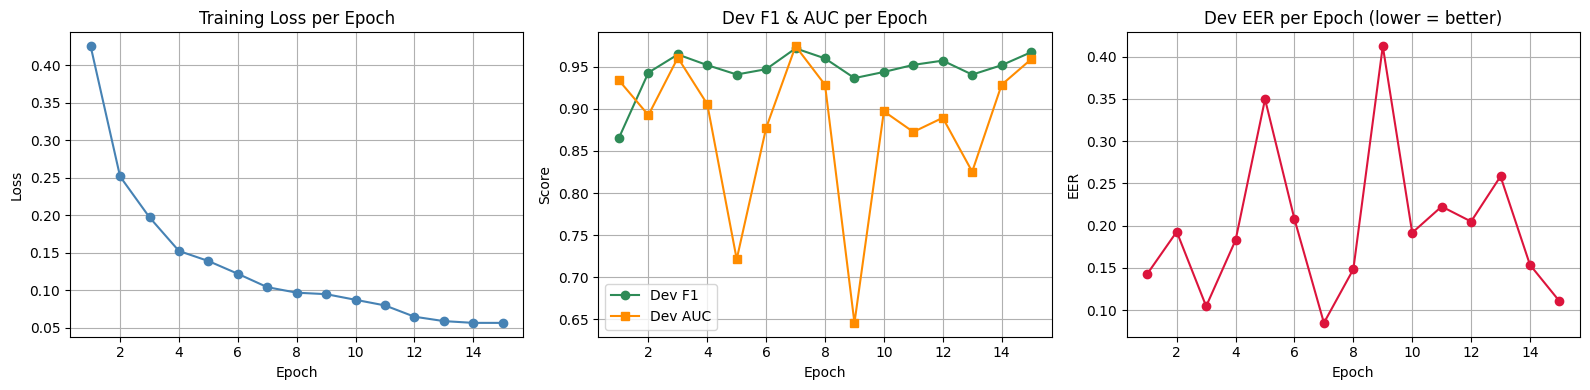

Saved → training_curves.png


In [23]:
# ---- Plot training curves ----
epochs_list  = [r["epoch"]     for r in history]
losses       = [r["train_loss"] for r in history]
dev_f1s      = [r["dev_f1"]    for r in history]
dev_aucs     = [r["dev_auc"]   for r in history]
dev_eers     = [r["dev_eer"]   for r in history]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_list, losses, marker="o", color="steelblue")
axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(epochs_list, dev_f1s,  marker="o", label="Dev F1",  color="seagreen")
axes[1].plot(epochs_list, dev_aucs, marker="s", label="Dev AUC", color="darkorange")
axes[1].set_title("Dev F1 & AUC per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs_list, dev_eers, marker="o", color="crimson")
axes[2].set_title("Dev EER per Epoch (lower = better)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("EER")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_curves.png")

# Evaluation

In [ ]:
# === Load Best Check Point ===
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Loaded best checkpoint:", best_path)

In [ ]:
# === Evaluate on Dev
y_dev, pred_dev, prob_dev, _ = predict_all(model, dev_loader)

print("DEV Accuracy:", accuracy_score(y_dev, pred_dev))
print("DEV F1:", f1_score(y_dev, pred_dev))
print("DEV ROC-AUC:", roc_auc_score(y_dev, prob_dev))
print("DEV EER:", compute_eer(y_dev, prob_dev))
print("DEV Confusion matrix:\n", confusion_matrix(y_dev, pred_dev))

In [ ]:
# == Evaluate on Eval

# ========================================================
# FINAL EVALUATION ON HELD-OUT EVAL SET
# ⚠️  Run this cell ONCE only - after all training and
#     hyperparameter decisions are fully finalised.
#     Do NOT use eval results to guide training choices.
# ========================================================

y_eval, pred_eval, prob_eval, _ = predict_all(model, eval_loader)

print("EVAL Accuracy:", accuracy_score(y_eval, pred_eval))
print("EVAL F1:", f1_score(y_eval, pred_eval))
print("EVAL ROC-AUC:", roc_auc_score(y_eval, prob_eval))
print("EVAL EER:", compute_eer(y_eval, prob_eval))
print("EVAL Confusion matrix:\n", confusion_matrix(y_eval, pred_eval))

## Confusion Matrices

In [ ]:
# ---- Confusion matrix heatmaps (Dev + Eval) ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_dev,  pred_dev,  "Dev Set"),
    (axes[1], y_eval, pred_eval, "Eval Set"),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Bonafide", "Spoof"],
        yticklabels=["Bonafide", "Spoof"]
    )
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrices.png")

In [ ]:
# === Export model thats ready for inference ==
export_path = "spoof_cnn_v4_state_dict.pth"
torch.save(model.state_dict(), export_path)
export_path

# Export & Inference Demo
**demonstrates how Pipeline A will be called inside my app backend**

**audio -> log-mel -> CNN -> spoof probabilty**

In [ ]:
#=== Inference Function ==
@torch.no_grad()
def predict_file(path_to_audio: str):
    path = Path(path_to_audio)
    wav = load_audio(path, cfg.target_sr)
    wav = fix_length(wav, int(cfg.clip_seconds * cfg.target_sr))

    wav_gpu = wav.to(device)
    feat = extractor(wav_gpu)          # (1, n_mels, frames)
    x = feat.unsqueeze(0)              # (B=1, 1, n_mels, frames)

    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    bonafide_p = float(probs[0])
    spoof_p = float(probs[1])
    pred = int(np.argmax(probs))

    return {
        "pred_label": "spoof" if pred == 1 else "bonafide",
        "spoof_probability": spoof_p,
        "bonafide_probability": bonafide_p
    }

In [ ]:
#=== Try a Dev file===
sample_utt, _ = dev_items[0]
sample_path = dev_dir / f"{sample_utt}.flac"
print("Sample path:", sample_path)

predict_file(str(sample_path))

In [ ]:
#check with one bonafide and one spoof from DEV
bonafide_utt = next(u for u,l in dev_items if l == 0)
spoof_utt    = next(u for u,l in dev_items if l == 1)

bonafide_path = dev_dir / f"{bonafide_utt}.flac"
spoof_path    = dev_dir / f"{spoof_utt}.flac"

print("Bonafide example:", bonafide_path)
print("Spoof example:   ", spoof_path)

print("Bonafide prediction:", predict_file(str(bonafide_path)))
print("Spoof prediction:   ", predict_file(str(spoof_path)))

## Plotting Spectrograms

In [ ]:
#Plotting spectogram images

def show_logmel(path_to_audio: str, title=""):
    wav = load_audio(Path(path_to_audio), cfg.target_sr)
    wav = fix_length(wav, int(cfg.clip_seconds * cfg.target_sr))

    with torch.no_grad():
        feat = extractor(wav.to(device)).cpu().squeeze(0)  # (n_mels, frames)

    plt.figure()
    plt.imshow(feat.numpy(), aspect="auto", origin="lower")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Frames")
    plt.ylabel("Mel bins")
    plt.show()

show_logmel(str(bonafide_path), "Bonafide log-mel")
show_logmel(str(spoof_path), "Spoof log-mel")